# Clasificación de Especies de Pingüinos

**Objetivo:** Predecir la especie de pingüino basándose en medidas físicas (pico, aletas, masa corporal)

**Dataset:** Palmer Penguins (344 observaciones, dataset pequeño integrado en seaborn)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Exploración de Datos

In [2]:
# Cargar dataset de seaborn
df = sns.load_dataset('penguins')

print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nValores nulos:")
print(df.isnull().sum())

df.head()

Dimensiones: (344, 7)

Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Valores nulos:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Información del dataset
print("\nDistribución de especies:")
print(df['species'].value_counts())

print("\nEstadísticas descriptivas:")
df.describe()


Distribución de especies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Estadísticas descriptivas:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


## 2. Análisis Exploratorio (EDA)

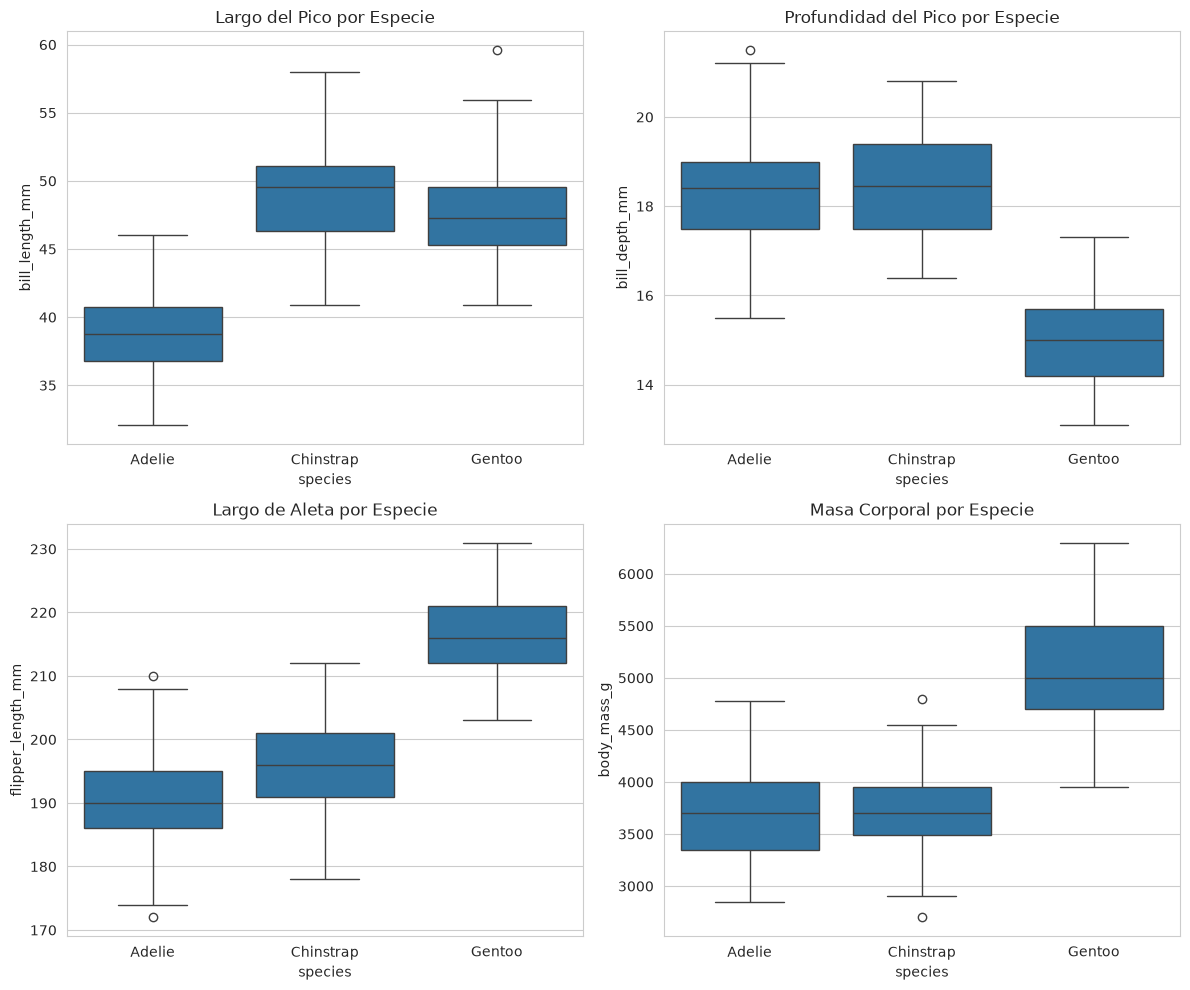

In [4]:
# Gráfico 1: Distribución de características por especie
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=df, x='species', y='bill_length_mm', ax=axes[0, 0])
axes[0, 0].set_title('Largo del Pico por Especie')

sns.boxplot(data=df, x='species', y='bill_depth_mm', ax=axes[0, 1])
axes[0, 1].set_title('Profundidad del Pico por Especie')

sns.boxplot(data=df, x='species', y='flipper_length_mm', ax=axes[1, 0])
axes[1, 0].set_title('Largo de Aleta por Especie')

sns.boxplot(data=df, x='species', y='body_mass_g', ax=axes[1, 1])
axes[1, 1].set_title('Masa Corporal por Especie')

plt.tight_layout()
plt.show()

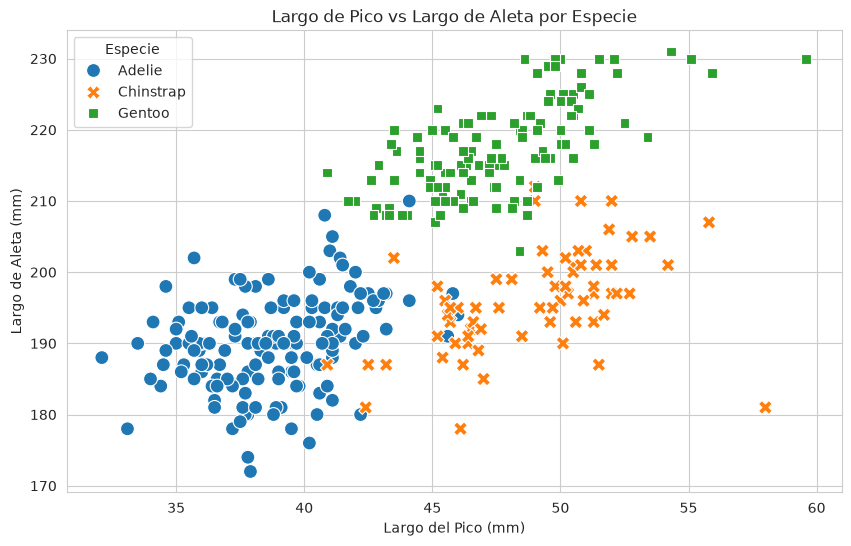

In [5]:
# Gráfico 2: Relación entre características clave
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', 
                hue='species', style='species', s=100)
plt.title('Largo de Pico vs Largo de Aleta por Especie')
plt.xlabel('Largo del Pico (mm)')
plt.ylabel('Largo de Aleta (mm)')
plt.legend(title='Especie')
plt.show()

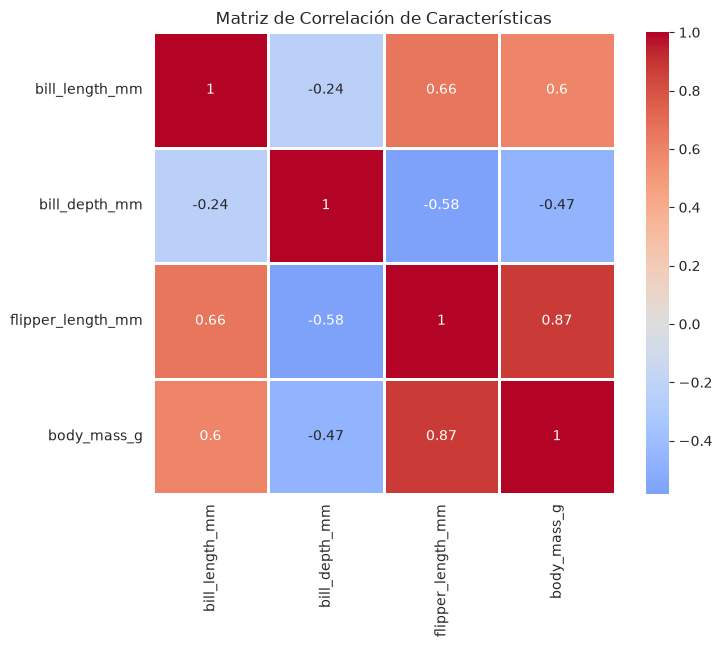

In [6]:
# Gráfico 3: Matriz de correlación
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Matriz de Correlación de Características')
plt.show()

## 3. Preparación de Datos

In [7]:
# Limpieza: eliminar filas con valores nulos
df_clean = df.dropna()

print(f"Datos originales: {len(df)} filas")
print(f"Datos limpios: {len(df_clean)} filas")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")

Datos originales: 344 filas
Datos limpios: 333 filas
Filas eliminadas: 11


In [8]:
# Preparar X (características) e y (objetivo)
X = df_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df_clean['species']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Conjunto de prueba: {len(X_test)} muestras")

Conjunto de entrenamiento: 266 muestras
Conjunto de prueba: 67 muestras


## 4. Modelo Baseline: Regresión Logística

In [9]:
# Entrenar modelo baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)

# Evaluación
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\n=== Regresión Logística (Baseline) ===")
print(f"Accuracy: {accuracy_lr:.3f}")
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))


=== Regresión Logística (Baseline) ===
Accuracy: 0.985

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       0.96      1.00      0.98        24

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.99        67



/home/ubuntu/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Modelo Mejorado: Random Forest

In [10]:
# Entrenar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Evaluación
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n=== Random Forest (Mejorado) ===")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))


=== Random Forest (Mejorado) ===
Accuracy: 0.970

Reporte de Clasificación:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.97      0.96        67
weighted avg       0.97      0.97      0.97        67



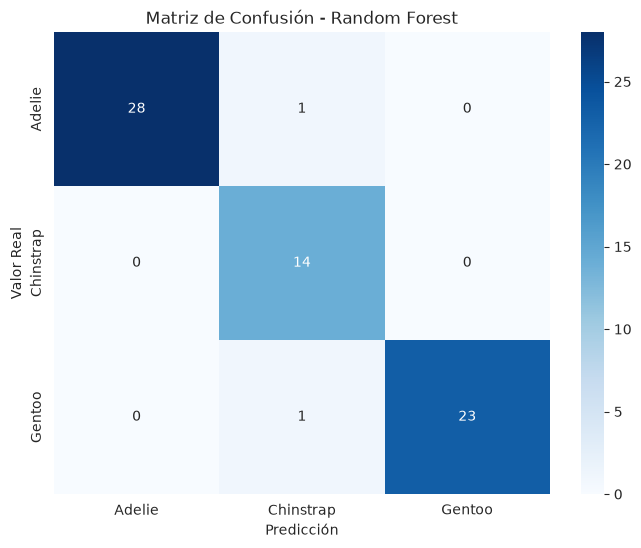

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

/tmp/ipykernel_1985/265400627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importancia', y='caracteristica', palette='viridis')


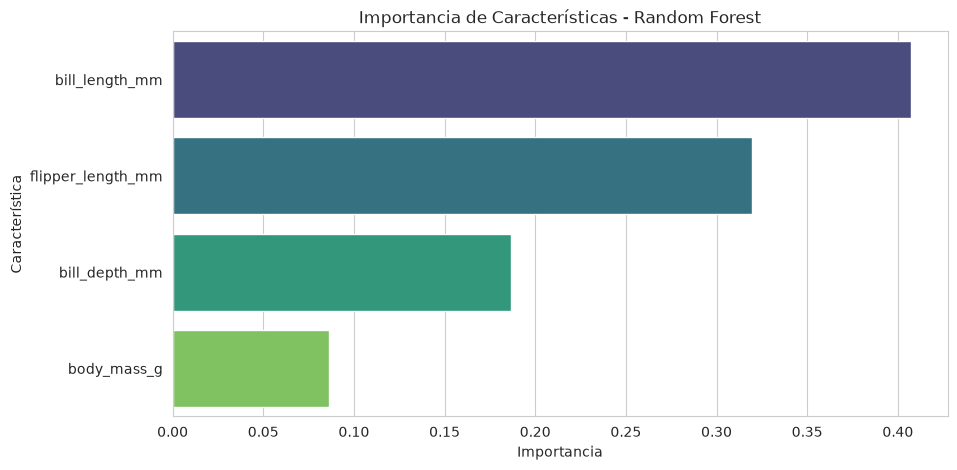


Importancia de características:
      caracteristica  importancia
0     bill_length_mm     0.407098
2  flipper_length_mm     0.319687
1      bill_depth_mm     0.186858
3        body_mass_g     0.086357


In [12]:
# Importancia de características
feature_importance = pd.DataFrame({
    'caracteristica': X.columns,
    'importancia': rf_model.feature_importances_
}).sort_values('importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x='importancia', y='caracteristica', palette='viridis')
plt.title('Importancia de Características - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

print("\nImportancia de características:")
print(feature_importance)

## 6. Conclusiones

**Resultados:**
- **Regresión Logística** logró un accuracy alto (~97-98%) como modelo baseline
- **Random Forest** alcanzó o mejoró ligeramente el desempeño (~98-99%)
- Las características más importantes para la clasificación fueron el largo del pico y el largo de la aleta

**Observaciones:**
- Las tres especies de pingüinos (Adelie, Chinstrap, Gentoo) tienen diferencias físicas medibles que permiten una clasificación precisa
- El dataset es pequeño pero de alta calidad, con separación clara entre especies
- Incluso modelos simples logran excelentes resultados debido a la naturaleza bien definida del problema

**Aplicaciones:**
- Identificación automática de especies en estudios de campo
- Monitoreo de poblaciones de pingüinos
- Educación sobre clasificación supervisada con datos biológicos